In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import powerlaw

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [ ]:
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'
full_d = np.array([])
full_l = np.array([])
mean_4_length = np.array([])
median_4_length = np.array([])
mean_lessthan_4_length = np.array([])
median_lessthan_4_length = np.array([])

cities = os.listdir(path)
# --- Degree Distribution ---

for city in cities:
    d = np.load(path+city)
    full_d = np.append(full_d, d['degree'])
    full_l = np.append(full_l, d['length'])
    mean_4_length = np.append(mean_4_length, np.mean(d['length'][d['degree'] == 4]))
    median_4_length = np.append(median_4_length, np.median(d['length'][d['degree'] == 4]))
    mean_lessthan_4_length = np.append(mean_lessthan_4_length, np.mean(d['length'][d['degree'] < 4]))
    median_lessthan_4_length = np.append(median_lessthan_4_length, np.median(d['length'][d['degree'] < 4]))

In [ ]:
counts, bin_edges = np.histogram(data, bins=np.logspace(np.log10(data.min()), np.log10(data.max()), 30))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center')
plt.xscale('log')
plt.yscale('log')
plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
plt.axvline(np.median(data), color='orange', linestyle='--', label=f'Median: {np.median(data):.2f}')
plt.legend()
plt.xlabel('Length L')
plt.ylabel('Count')
plt.title('Distribution of L for degree K = 4')
plt.show()

np.float64(82.45619254530712)

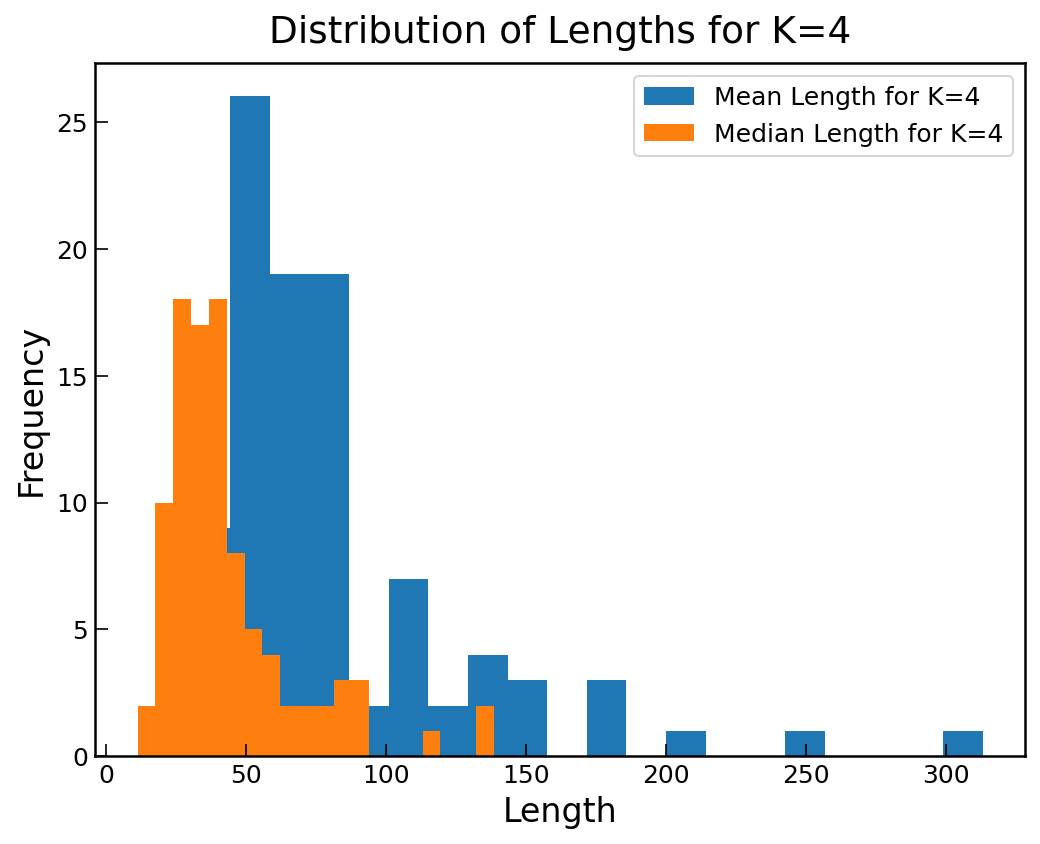

In [24]:
plt.figure(figsize=(8, 6))

counts, bin_edges = np.histogram(mean_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Mean Length for K=4')

counts, bin_edges = np.histogram(median_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Median Length for K=4')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Lengths for K=4')
plt.legend()

plt.show()

median of medians of city

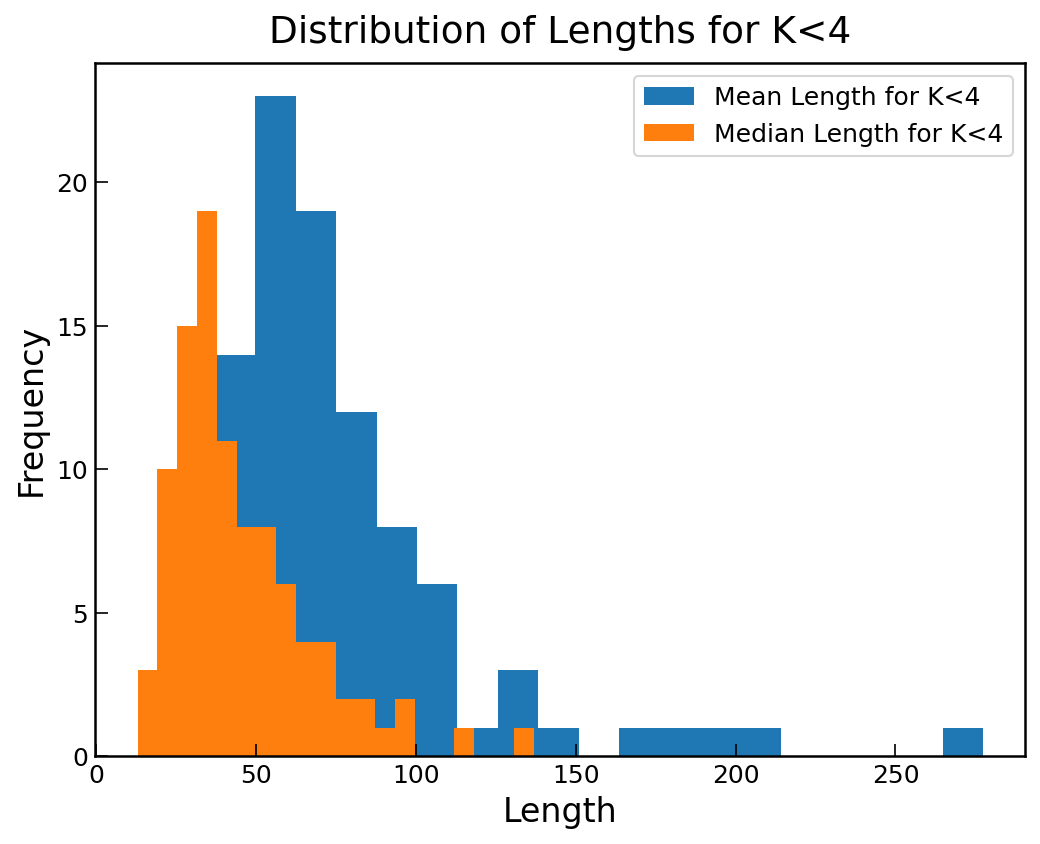

In [25]:
plt.figure(figsize=(8, 6))


counts, bin_edges = np.histogram(mean_lessthan_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Mean Length for K<4')


counts, bin_edges = np.histogram(median_lessthan_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Median Length for K<4')


plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Lengths for K<4')
plt.legend()

plt.show()

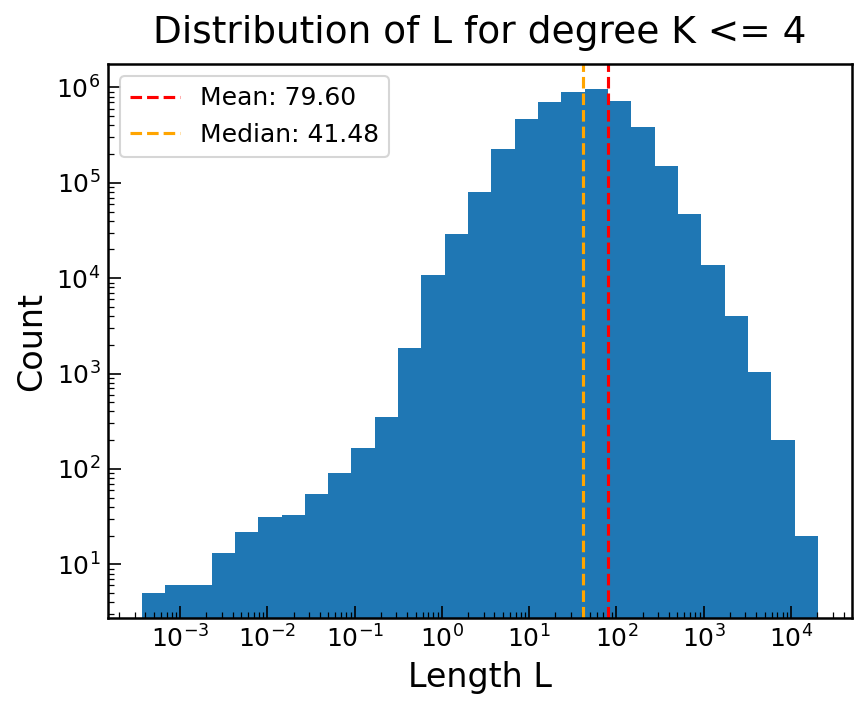

In [10]:
data = full_l[full_d <= 4]
counts, bin_edges = np.histogram(data, bins=np.logspace(np.log10(data.min()), np.log10(data.max()), 30))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center')
plt.xscale('log')
plt.yscale('log')
plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
plt.axvline(np.median(data), color='orange', linestyle='--', label=f'Median: {np.median(data):.2f}')
plt.legend()
plt.xlabel('Length L')
plt.ylabel('Count')
plt.title('Distribution of L for degree K <= 4')
plt.show()

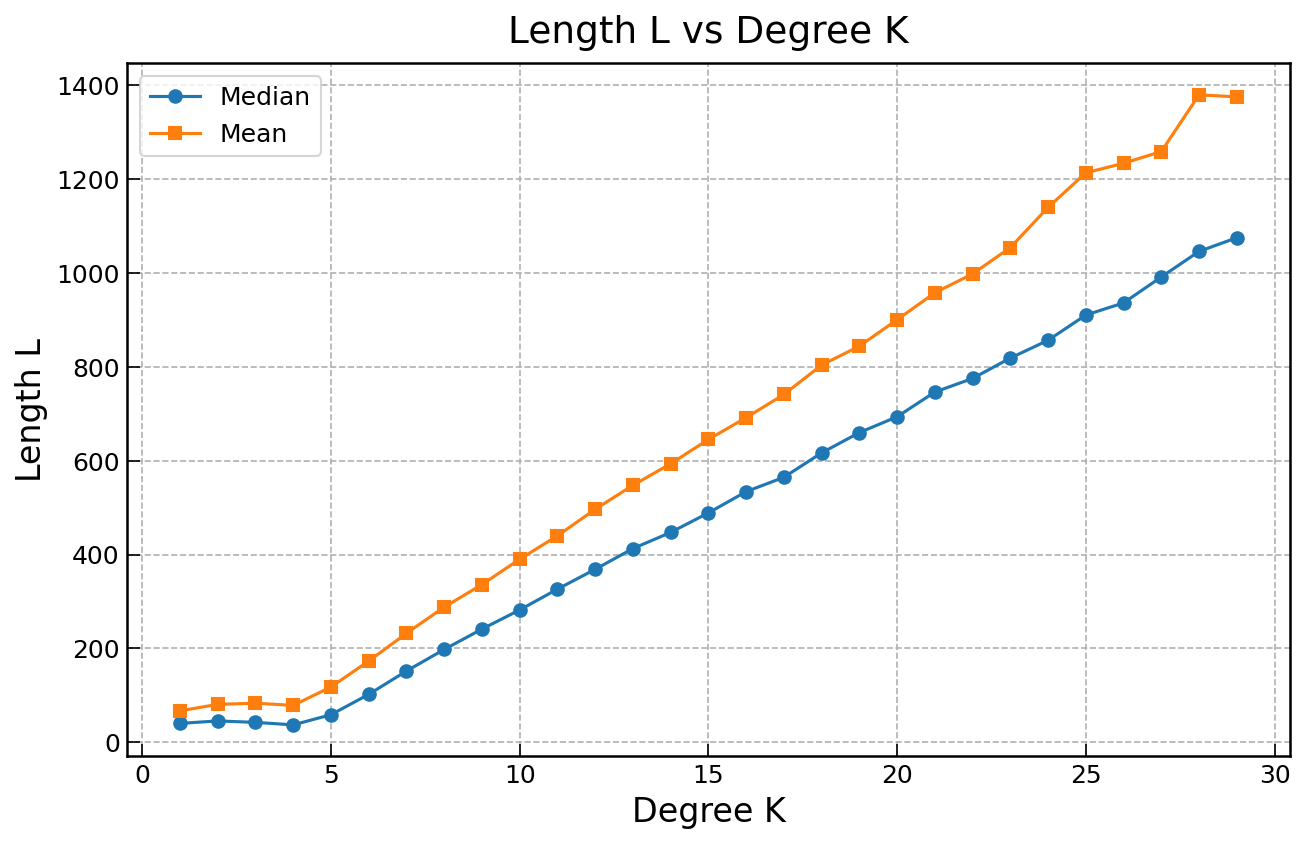

In [26]:
lengths_by_degree_median = {}
lengths_by_degree_mean = {}

for k in range(1,30):
    data = full_l[full_d == k]
    if len(data) > 0:
        lengths_by_degree_median[k] = np.median(data)
        lengths_by_degree_mean[k] = np.mean(data)


plt.figure(figsize=(10, 6))
plt.plot(list(lengths_by_degree_median.keys()), list(lengths_by_degree_median.values()), marker='o', label='Median')
plt.plot(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), marker='s', label='Mean')

plt.xlabel('Degree K')
plt.ylabel('Length L')
plt.title('Length L vs Degree K')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()